In [1]:
# --- Célula 1: Mudar Diretório ---
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
import torchtuples as tt
from pycox.models import LogisticHazard
from pycox.evaluation import EvalSurv
from sklearn.model_selection import train_test_split


# Agora o diretório de trabalho é a pasta raiz. A importação absoluta funciona diretamente.
from processamento import PassandoDados # biblioteca local
from funcaolog import get_callbacks, SaveFullModelCallback # biblioteca local

print("Importação bem-sucedida!")

Importação bem-sucedida!


# TESTE COM AMOSTRA

INFO:Processamento:Processando 756 pacientes válidos
Processando pacientes: 100%|██████████| 756/756 [00:15<00:00, 49.32it/s]
INFO:Processamento:Processamento concluído: 756 pacientes carregados
INFO:Processamento:Parâmetros: limite_features=12000, limite_labels=None, metodo=elgendi2010
INFO:Processamento:DataLoaders criados - Treino: 604, Teste: 152


0:	[2s / 2s],		train_loss: 11.2296,	val_loss: 10.2277
1:	[2s / 4s],		train_loss: 11.0930,	val_loss: 10.1215
2:	[2s / 7s],		train_loss: 11.0294,	val_loss: 10.0090
3:	[2s / 9s],		train_loss: 10.8831,	val_loss: 9.8800
4:	[2s / 11s],		train_loss: 10.7197,	val_loss: 9.7284
5:	[2s / 14s],		train_loss: 10.5615,	val_loss: 9.5508
6:	[2s / 16s],		train_loss: 10.3510,	val_loss: 9.3377
7:	[3s / 20s],		train_loss: 10.0740,	val_loss: 9.0793
8:	[2s / 22s],		train_loss: 9.7755,	val_loss: 8.7690
9:	[3s / 25s],		train_loss: 9.4015,	val_loss: 8.3948
10:	[2s / 28s],		train_loss: 8.9782,	val_loss: 7.9490
11:	[2s / 30s],		train_loss: 8.4266,	val_loss: 7.4274
12:	[2s / 32s],		train_loss: 7.8305,	val_loss: 6.8319
13:	[2s / 34s],		train_loss: 7.1559,	val_loss: 6.1734
14:	[2s / 37s],		train_loss: 6.4001,	val_loss: 5.4683
15:	[2s / 39s],		train_loss: 5.6208,	val_loss: 4.7468
16:	[2s / 42s],		train_loss: 4.8277,	val_loss: 4.0421
17:	[2s / 44s],		train_loss: 4.0627,	val_loss: 3.3884
18:	[2s / 47s],		train_loss: 3.

c:\Users\danie\anaconda3\envs\regressao_cox\Lib\site-packages\torchtuples\base.py:669: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.net.load_state_dict(torch.load(path

29:	[2s / 1m:13s],		train_loss: 0.8435,	val_loss: 1.0220


2025/10/07 12:04:58 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2025/10/07 12:04:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Modelo final salvo em: D:\cox-models-sudden-death\Arquitetura\logs\checkpoints\TESTEnet1d_model1minlimpo.pth


Registered model 'TESTEnet1d_model1minlimpo' already exists. Creating a new version of this model...
2025/10/07 12:05:08 WARNING mlflow.tracking._model_registry.fluent: Run with id 88618a5d57c04451947bea4e83dd6e5d has no artifacts at artifact path 'TESTEnet1d_model1minlimpo', registering model based on models:/m-5de6a9d8a42c4cfabe73c2f95fe03f78 instead
Created version '19' of model 'TESTEnet1d_model1minlimpo'.


✅ Treinamento e log concluídos no MLflow!
--- Plot da Perda de Treinamento e Validação ---


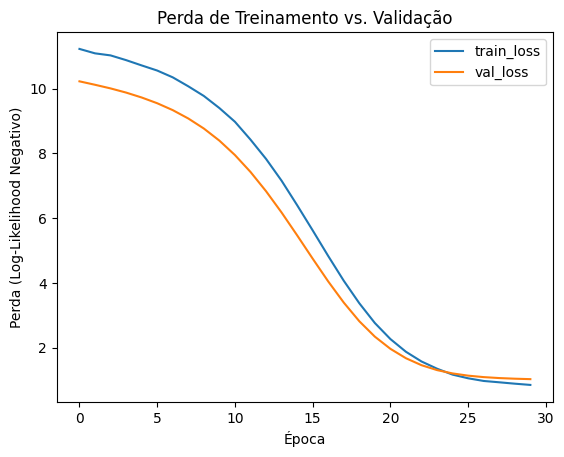

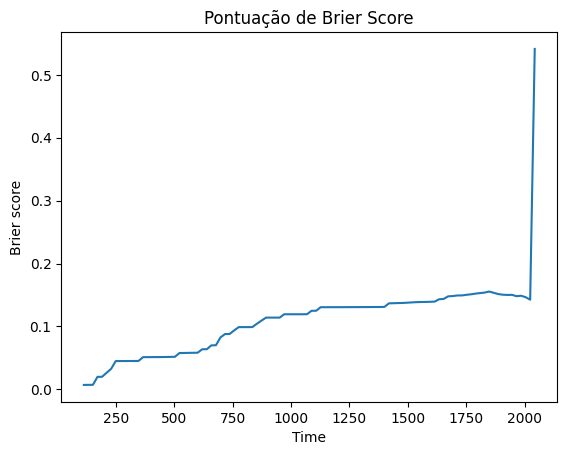

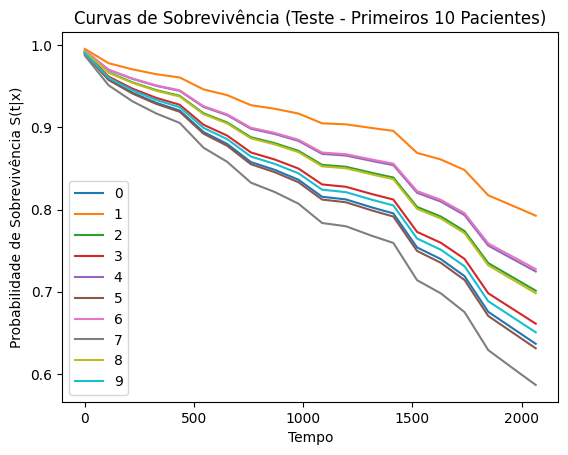

C-index (time-dependent): 0.4626
Integrated Brier Score: 0.14100348450057282
Integrated NLL: 0.4786


In [1]:
from processamento_amostra import PassandoDadosAmostra # biblioteca local
from funcaolog  import get_callbacks # biblioteca local
from metrica_grafico import manual_integrated_nbll, manual_integrated_brier_score # biblioteca local

import mlflow
import mlflow.pytorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchtuples as tt
from torchtuples.callbacks import Callback  # <--- IMPORTANTE
from pycox.models import LogisticHazard
import matplotlib.pyplot as plt
from pycox.evaluation import EvalSurv
import os
import numpy as np

# ============================================
# 0. Preparação dos dados
# ============================================
tensores = PassandoDadosAmostra(limite_features=12000, usar_limpeza=True)
dl_treino, dl_teste = tensores.convert_to_tensors()
tempos_teste_np, eventos_teste_np = tensores.get_evento_tempo()
amostra_mlflow = tensores.get_amostra_sinal()
labtrans = tensores.get_labtrans()

modelo = "TESTEnet1d_model1minlimpo"

# ============================================
# 1. ARQUITETURA CNN 1D
# ============================================
class Net1D(nn.Module):
    def __init__(self, out_features):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=3, out_channels=16, kernel_size=5, stride=1)
        self.max_pool = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(16, 16, 5, 1)
        self.glob_avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Linear(16, 16)
        self.fc2 = nn.Linear(16, out_features)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.max_pool(x)
        x = F.relu(self.conv2(x))
        x = self.glob_avg_pool(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# ============================================
# 2. CALLBACK para logar métricas no MLflow
# ============================================
class MLflowLogger(Callback):
    """Callback que loga métricas de treino e validação no MLflow a cada época."""
    def on_epoch_end(self):
        # Obtém a última linha do log (época atual)
        logs = self.model.log.to_pandas().iloc[-1]
        # A época atual é o tamanho do log menos 1
        current_epoch = len(self.model.log.to_pandas()) - 1
        # Loga métricas no MLflow
        mlflow.log_metric("train_loss", logs["train_loss"], step=current_epoch)
        mlflow.log_metric("val_loss", logs["val_loss"], step=current_epoch)


# ============================================
# 3. INICIANDO EXPERIMENTO MLflow
# ============================================
mlflow.set_tracking_uri("file:///D:/cox-models-sudden-death/Arquitetura/logs/mlruns")
mlflow.set_experiment("TESTEecg_cox_experiment")

args = {'lr': 1e-3, 'weight_decay': 1e-7}

with mlflow.start_run(run_name="TESTENet1D Cox Model1minlimpov3"):
    # -------------------
    # 3.1 Modelo
    # -------------------
    net_1d = Net1D(labtrans.out_features)
    optimizer = tt.optim.Adam(args['lr'])
    model = LogisticHazard(net_1d, optimizer, duration_index=labtrans.cuts)

    # -------------------
    # 3.2 Callbacks (inclui o MLflowLogger)
    # -------------------
    callbacks = [get_callbacks(), MLflowLogger()]

    # -------------------
    # 3.3 Treinamento
    # -------------------
    epochs = 30
    log = model.fit_dataloader(dl_treino, epochs, callbacks, True, val_dataloader=dl_teste)

    # -------------------
    # 3.4 Log e salvamento
    # -------------------
    df_log = log.to_pandas()

    save_dir = r"D:\cox-models-sudden-death\Arquitetura\logs\checkpoints"
    os.makedirs(save_dir, exist_ok=True)
    
    mlflow.pytorch.log_model(model.net, modelo)
    model_path = os.path.join(save_dir, f"{modelo}.pth")
    torch.save(model.net.state_dict(), model_path)
    print(f"✅ Modelo final salvo em: {model_path}")
    
    mlflow.pytorch.log_model(net_1d, modelo, input_example=amostra_mlflow)
    
    mlflow.register_model(
        f"runs:/{mlflow.active_run().info.run_id}/{modelo}",
        name=modelo
    )

    # -------------------
    # 3.5 Parâmetros e artefatos
    # -------------------
    mlflow.log_param("epochs", epochs)
    mlflow.log_param("learning_rate", args['lr'])
    mlflow.log_param("batch_size", dl_treino.batch_size)

    mlflow.log_artifact(model_path)
    
    # -------------------
    # 2.7 Salvando artefatos (logs/checkpoints)
    # -------------------
    mlflow.log_artifact(fr"D:\cox-models-sudden-death\Arquitetura\logs\checkpoints\{modelo}.pth")
    mlflow.log_artifact(r"D:\cox-models-sudden-death\Arquitetura\logs\processamento_dados.log")

    print("✅ Treinamento e log concluídos no MLflow!")
    
    #=======================GRÁFICOS============================================
    # Diretório para salvar imagens localmente
    
    figures_dir = r"D:\cox-models-sudden-death\Arquitetura\logs\figuras"
    os.makedirs(figures_dir, exist_ok=True)
    
    # --- Plot da perda ---
    print("--- Plot da Perda de Treinamento e Validação ---")
    _ = log.plot()
    plt.title("Perda de Treinamento vs. Validação")
    plt.ylabel('Perda (Log-Likelihood Negativo)')
    plt.xlabel('Época')
    figura_perda_path = os.path.join(figures_dir, "perda_treino_val.png")
    plt.savefig(figura_perda_path)
    plt.show()
    # Log da figura no MLflow
    mlflow.log_artifact(figura_perda_path)

    # --- Avaliação no conjunto de teste ---
    dl_teste_x = tt.data.dataloader_input_only(dl_teste)
    curvas_sobrevida = model.interpolate(10).predict_surv_df(dl_teste_x)
    ev = EvalSurv(curvas_sobrevida, tempos_teste_np, eventos_teste_np, censor_surv='km')
      
    # Pontuação de Brier Score
    time_grid = np.linspace(tempos_teste_np.min(), tempos_teste_np.max(), 100)
    ev.brier_score(time_grid).plot()
    plt.title("Pontuação de Brier Score")
    plt.ylabel('Brier score')
    brier_path = os.path.join(figures_dir, "Brier_Score.png")
    plt.savefig(brier_path)
    _ = plt.xlabel('Time')
    # Log da figura no MLflow
    mlflow.log_artifact(brier_path)


    # --- Plot das curvas de sobrevivência ---
    curvas_sobrevida.iloc[:, :10].plot()
    plt.ylabel('Probabilidade de Sobrevivência S(t|x)')
    plt.xlabel('Tempo')
    plt.title("Curvas de Sobrevivência (Teste - Primeiros 10 Pacientes)")
    curvas_path = os.path.join(figures_dir, "curvas_sobrevida.png")
    plt.savefig(curvas_path)
    plt.show()
    # Log da figura no MLflow
    mlflow.log_artifact(curvas_path)
    
    #=======================MÉTRICAS============================================
    
    # C-index
    c_index = ev.concordance_td()
    print(f"C-index (time-dependent): {c_index:.4f}")
    mlflow.log_metric("c_index", c_index)    
    
    # # # Integrated Brier Score
    # int_brier_score = ev.integrated_brier_score(time_grid)
    # print(f'Integrated Brier Score: {int_brier_score:.4f}')
    # mlflow.log_metric("integrated_brier_score", int_brier_score)
    

    # # Integrated Negative Binomial Log-Likelihood
    # int_nbll = ev.integrated_nbll(time_grid)
    # print(f'Integrated NLL: {int_nbll:.4f}')
    # mlflow.log_metric("integrated_nbll", int_nbll)
    
    # Integrated Brier Score (MANUAL)
    int_brier_score = manual_integrated_brier_score(curvas_sobrevida, tempos_teste_np, eventos_teste_np, time_grid)
    # print(f'Integrated Brier Score: {int_brier_score:.4f}')
    print(f'Integrated Brier Score: {int_brier_score}')
    mlflow.log_metric("integrated_brier_score", int_brier_score)

    # Integrated Negative Binomial Log-Likelihood (MANUAL)
    int_nbll = manual_integrated_nbll(curvas_sobrevida, tempos_teste_np, eventos_teste_np, time_grid)
    print(f'Integrated NLL: {int_nbll:.4f}')
    mlflow.log_metric("integrated_nbll", int_nbll)
    
    


# MODELO - GERADOR DE AMOSTRA

CPU times: total: 0 ns
Wall time: 0 ns
🚀 INICIANDO TREINAMENTO COM GERADOR (LAZY LOADING)

📦 ETAPA 1: Carregando e preparando dados...
📊 Total de pacientes encontrados: 756
   - Treino:    453 pacientes
   - Validação: 151 pacientes
   - Teste:     152 pacientes
🔄 Configurando labtrans (usando apenas dados de treino)...
✅ Labtrans configurado com 20 durações

📊 Informações do Dataset:
   - Pacientes de Treino: 453
   - Pacientes de Validação: 151
   - Pacientes de Teste: 152
   - Steps por Época (Treino): 4
   - Steps por Época (Val): 2

🔧 ETAPA 2: Configurando modelo e MLflow...

🎯 ETAPA 3: Iniciando loop de treinamento...

📊 ÉPOCA 1/5
----------------------------------------------------------------------

✅ Época 1 Completa:
   - Train Loss: 11.2385
   - Val Loss:   10.6976
   - Val C-Index:  0.5537

📊 ÉPOCA 2/5
----------------------------------------------------------------------

✅ Época 2 Completa:
   - Train Loss: 11.0473
   - Val Loss:   10.5594
   - Val C-Index:  0.5622

📊 ÉPO

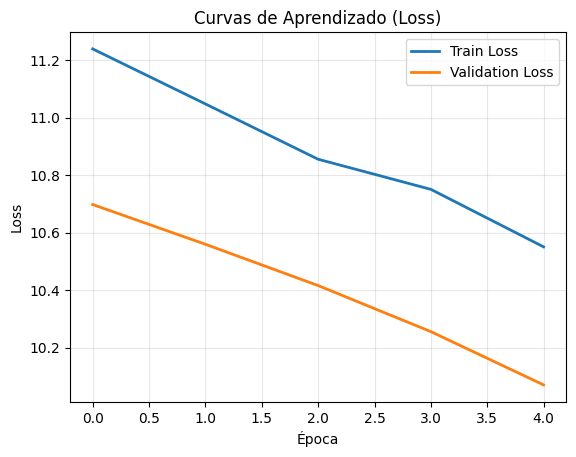

   ✅ Gráfico 'curvas_loss.png' salvo.


<Figure size 640x480 with 0 Axes>

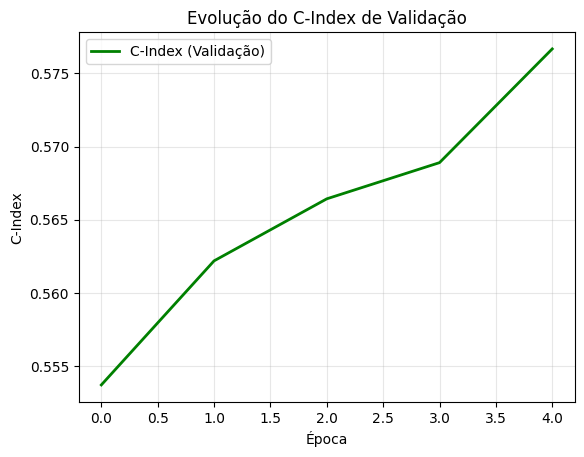

   ✅ Gráfico 'c_index_evolucao.png' salvo.


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

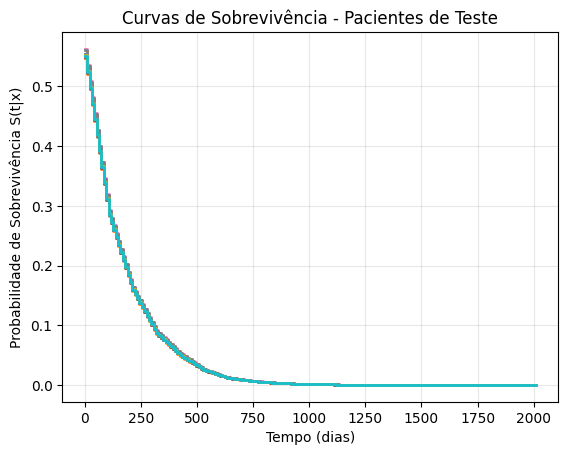

   ✅ Gráfico 'curvas_sobrevida.png' salvo.


<Figure size 640x480 with 0 Axes>

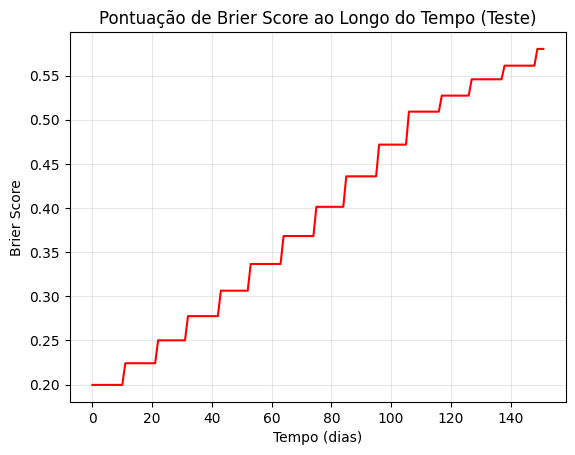

2025/10/07 21:53:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


   ✅ Gráfico 'brier_score_curva.png' salvo.


2025/10/07 21:53:18 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


   ✅ Modelo final salvo em: D:\cox-models-sudden-death\Arquitetura\logs\checkpoints\TESTEnet1d_model1minlimpog1.pth

🎉 TREINAMENTO CONCLUÍDO COM SUCESSO!


<Figure size 640x480 with 0 Axes>

In [ ]:
# treinamento.py
%time
import mlflow
import mlflow.pytorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchtuples as tt
from pycox.models import LogisticHazard
from pycox.evaluation import EvalSurv
import matplotlib.pyplot as plt
import numpy as np
import os

# Importa a classe do arquivo de processamento
from processamento import PassandoDados
# from funcaolog import get_callbacks # Esta importação não está sendo usada no código
from metrica_grafico import manual_integrated_nbll, manual_integrated_brier_score # biblioteca local


modelo = "TESTEnet1d_model20minlimpog1"

# ============================================
# 1. DEFINIÇÃO DA ARQUITETURA
# ============================================
class Net1D(nn.Module):
    def __init__(self, out_features):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=3, out_channels=16, kernel_size=5, stride=1)
        self.max_pool = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(16, 16, 5, 1)
        self.glob_avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Linear(16, 16)
        self.fc2 = nn.Linear(16, out_features)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.max_pool(x)
        x = F.relu(self.conv2(x))
        x = self.glob_avg_pool(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x



# A função de avaliação agora deve ser usada com o conjunto de VALIDAÇÃO durante o treino
def evaluate_metrics(model, generator, steps, batch_size):
    """
    Coleta todas as predições e dados de um gerador e retorna as curvas,
    os dados reais (tempos, eventos) e as métricas calculadas (c-index).
    """
    model.net.eval()
    
    all_sinais = []
    all_tempos = []
    all_eventos = []

    for _ in range(steps):
        sinais, tempos, eventos = next(generator)
        all_sinais.append(sinais)
        all_tempos.extend(tempos)
        all_eventos.extend(eventos)
        
    all_sinais_tensor = torch.cat(all_sinais, dim=0)
    tempos_reais_np = np.array(all_tempos)
    eventos_reais_np = np.array(all_eventos)

    # Predições de sobrevivência
    with torch.no_grad():
        if next(model.net.parameters()).is_cuda:
            all_sinais_tensor = all_sinais_tensor.cuda()
        surv_df = model.interpolate(10).predict_surv_df(all_sinais_tensor)

    # Calcular métricas com EvalSurv
    ev = EvalSurv(surv_df, tempos_reais_np, eventos_reais_np, censor_surv='km')
    c_index = ev.concordance_td()
    
    # ✅ RETORNAR TUDO O QUE PRECISAMOS
    #return c_index, surv_df, tempos_reais_np, eventos_reais_np, ev.time_grid
    return ev, surv_df, tempos_reais_np, eventos_reais_np

      

# ============================================
# 2. TREINAMENTO COM GERADOR
# ============================================

"""Treinamento usando gerador (lazy loading)"""

print("=" * 70)
print("🚀 INICIANDO TREINAMENTO COM GERADOR (LAZY LOADING)")
print("=" * 70)

# Configurações
LIMITE_FEATURES = 12000  # Amostras por paciente (1 min a 200Hz)
# LIMITE_LABELS = 100    # Descomente para limitar o número de pacientes
BATCH_SIZE = 128
NUM_EPOCHS = 10
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-7

# ============================================
# ETAPA 1: PREPARAR DADOS
# ============================================
print("\n📦 ETAPA 1: Carregando e preparando dados...")

processor = PassandoDados(
    limite_features=LIMITE_FEATURES, 
    batch_size=BATCH_SIZE
)

generators = processor.preparar_dados()
labtrans = processor.get_labtrans()

print(f"\n📊 Informações do Dataset:")
print(f"   - Pacientes de Treino: {generators['num_train_samples']}")
print(f"   - Pacientes de Validação: {generators['num_val_samples']}") # ✅ NOVO
print(f"   - Pacientes de Teste: {generators['num_test_samples']}")
print(f"   - Steps por Época (Treino): {generators['steps_per_epoch_train']}")
print(f"   - Steps por Época (Val): {generators['steps_per_epoch_val']}") # ✅ NOVO

# ============================================
# ETAPA 2: CONFIGURAR MODELO E MLFLOW
# ============================================
print("\n🔧 ETAPA 2: Configurando modelo e MLflow...")

mlflow.set_tracking_uri("file:///D:/cox-models-sudden-death/Arquitetura/logs/mlruns")
mlflow.set_experiment("TESTEecg_cox_experiment")

# Final_ECG_Cox_Experiment 

with mlflow.start_run(run_name="Net1D_Cox_Model_Generator20minlimpog1"):
    
    # Criar modelo
    net_1d = Net1D(labtrans.out_features)
    optimizer = tt.optim.Adam(LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    model = LogisticHazard(net_1d, optimizer, duration_index=labtrans.cuts)
    
    # Log de hiperparâmetros
    mlflow.log_params({
        'lr': LEARNING_RATE,
        'weight_decay': WEIGHT_DECAY,
        'epochs': NUM_EPOCHS,
        'batch_size': BATCH_SIZE,
        'limite_features': LIMITE_FEATURES,
        'num_durations': labtrans.out_features
    })
    
    # ✅ ETAPA 3: LOOP DE TREINAMENTO
    print("\n🎯 ETAPA 3: Iniciando loop de treinamento...")
    print("=" * 70)
    
    train_losses, val_losses, c_indices_val = [], [], []
    val_generator = generators['val_generator']

    for epoch in range(NUM_EPOCHS):
        print(f"\n📊 ÉPOCA {epoch+1}/{NUM_EPOCHS}")
        print("-" * 70)
        
        # --- FASE DE TREINO (COM SHUFFLE) ---
        model.net.train()
        pacientes_treino_epoch = np.random.permutation(processor.pacientes_treino)
        train_generator_epoch = processor.ecg_generator(pacientes_treino_epoch, batch_size=BATCH_SIZE)
        epoch_train_loss = 0.0
        for step in range(generators['steps_per_epoch_train']):
            sinais, tempos, eventos = next(train_generator_epoch)
            idx_durations, events_transformed = labtrans.transform(tempos, eventos)
            idx_durations = torch.tensor(idx_durations, dtype=torch.int64)
            events_transformed = torch.tensor(events_transformed, dtype=torch.float32)
            if next(model.net.parameters()).is_cuda:
                sinais, idx_durations, events_transformed = sinais.cuda(), idx_durations.cuda(), events_transformed.cuda()
            optimizer.zero_grad()
            output = model.net(sinais)
            loss = model.loss(output, idx_durations, events_transformed)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()
        avg_train_loss = epoch_train_loss / generators['steps_per_epoch_train']
        train_losses.append(avg_train_loss)
        
        # --- FASE DE VALIDAÇÃO ---
        model.net.eval()
        epoch_val_loss = 0.0
        with torch.no_grad():
            for step in range(generators['steps_per_epoch_val']):
                sinais, tempos, eventos = next(val_generator)
                # ... (cálculo da val_loss, igual ao que você já tinha) ...
                idx_durations, events_transformed = labtrans.transform(tempos, eventos)
                idx_durations = torch.tensor(idx_durations, dtype=torch.int64)
                events_transformed = torch.tensor(events_transformed, dtype=torch.float32)
                if next(model.net.parameters()).is_cuda:
                    sinais, idx_durations, events_transformed = sinais.cuda(), idx_durations.cuda(), events_transformed.cuda()
                output = model.net(sinais)
                loss = model.loss(output, idx_durations, events_transformed)
                epoch_val_loss += loss.item()
        avg_val_loss = epoch_val_loss / generators['steps_per_epoch_val']
        val_losses.append(avg_val_loss)

        # --- AVALIAÇÃO DA ÉPOCA NO CONJUNTO DE VALIDAÇÃO ---
        ev_val, _, _, _ = evaluate_metrics(
        model, 
        val_generator, 
        generators['steps_per_epoch_val'], 
        BATCH_SIZE
        )
        
        c_index_epoch = ev_val.concordance_td()
        c_indices_val.append(c_index_epoch)
        
        # --- LOG DA ÉPOCA ---
        print(f"\n✅ Época {epoch+1} Completa:")
        print(f"   - Train Loss: {avg_train_loss:.4f}")
        print(f"   - Val Loss:   {avg_val_loss:.4f}")
        print(f"   - Val C-Index:  {c_index_epoch:.4f}")
        mlflow.log_metric("train_loss", avg_train_loss, step=epoch)
        mlflow.log_metric("val_loss", avg_val_loss, step=epoch)
        mlflow.log_metric("val_c_index", c_index_epoch, step=epoch)

    # ✅ ETAPA 4: AVALIAÇÃO FINAL E MÉTRICAS NO CONJUNTO DE TESTE
    print("\n" + "=" * 70)
    print("📈 ETAPA 4: Avaliação final no CONJUNTO DE TESTE")
    print("=" * 70)
    
    test_generator = generators['test_generator']
    # ✅ Desempacotar o objeto 'ev_test'
    ev_test, surv_df_test, tempos_test, eventos_test = evaluate_metrics(
        model,
        test_generator,
        generators['steps_per_epoch_test'],
        BATCH_SIZE
    )
    
    # Extrair métricas do objeto 'ev_test'
    final_c_index = ev_test.concordance_td()
    # time_grid = ev_test.time_grid # Usado para as métricas integradas
    time_grid = surv_df_test.columns.to_numpy() # Usado para as métricas integradas
    
    # C-index
    print(f"\n🎯 RESULTADO FINAL:")
    print(f"   - C-index de Validação (última época): {c_indices_val[-1]:.4f}")
    print(f"   - C-index de TESTE (final, imparcial): {final_c_index:.4f}")
    mlflow.log_metric("final_test_c_index", final_c_index)
    
    # Integrated Brier Score
    int_brier_score = manual_integrated_brier_score(surv_df_test, tempos_test, eventos_test, time_grid)
    print(f'   - Integrated Brier Score (TESTE): {int_brier_score:.4f}')
    mlflow.log_metric("integrated_brier_score", int_brier_score)

    # Integrated Negative Binomial Log-Likelihood
    int_nbll = manual_integrated_nbll(surv_df_test, tempos_test, eventos_test, time_grid)
    print(f'   - Integrated NLL (TESTE): {int_nbll:.4f}')
    mlflow.log_metric("integrated_nbll", int_nbll)

    # ✅ ETAPA 5: VISUALIZAÇÕES E SALVAMENTO
    print("\n📊 ETAPA 5: Gerando visualizações e salvando modelo...")
    
    # --- DEFINIR DIRETÓRIOS PARA SALVAR ---
    base_dir = r"D:\cox-models-sudden-death\Arquitetura\logs"
    figures_dir = os.path.join(base_dir, "figures")
    checkpoints_dir = os.path.join(base_dir, "checkpoints")
    os.makedirs(figures_dir, exist_ok=True)
    os.makedirs(checkpoints_dir, exist_ok=True)
    mlflow.log_artifact(r"D:\cox-models-sudden-death\Arquitetura\logs\processamento_dados.log")
    
    # --- GRÁFICO 1: Curvas de Aprendizado (Loss) ---
    plt.figure()
    plt.plot(train_losses, label='Train Loss', linewidth=2)
    plt.plot(val_losses, label='Validation Loss', linewidth=2)
    plt.xlabel('Época'); plt.ylabel('Loss'); plt.title('Curvas de Aprendizado (Loss)')
    plt.legend(); plt.grid(True, alpha=0.3)
    loss_path = os.path.join(figures_dir, "curvas_loss.png")
    plt.show()
    plt.savefig(loss_path, dpi=150); mlflow.log_artifact(loss_path)
    print(f"   ✅ Gráfico 'curvas_loss.png' salvo.")

    # --- GRÁFICO 2: Evolução do C-Index de Validação ---
    plt.figure()
    plt.plot(c_indices_val, label='C-Index (Validação)', linewidth=2, color='green')
    plt.xlabel('Época'); plt.ylabel('C-Index'); plt.title('Evolução do C-Index de Validação')
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.show()
    c_index_path = os.path.join(figures_dir, "c_index_evolucao.png")
    plt.savefig(c_index_path, dpi=150); mlflow.log_artifact(c_index_path)
    print(f"   ✅ Gráfico 'c_index_evolucao.png' salvo.")

    # --- GRÁFICO 3: Curvas de Sobrevivência ---
    plt.figure()
    surv_df_test.iloc[:, :10].plot(drawstyle='steps-post', linewidth=2)
    plt.ylabel('Probabilidade de Sobrevivência S(t|x)'); plt.xlabel('Tempo (dias)')
    plt.title("Curvas de Sobrevivência - Pacientes de Teste"); plt.grid(True, alpha=0.3)
    plt.legend()# .set_visible(False)
    plt.show()
    curvas_path = os.path.join(figures_dir, "curvas_sobrevida.png")
    plt.savefig(curvas_path, dpi=150, bbox_inches='tight'); mlflow.log_artifact(curvas_path)
    print(f"   ✅ Gráfico 'curvas_sobrevida.png' salvo.")

    # --- GRÁFICO 4: Pontuação de Brier Score ao Longo do Tempo ---
    plt.figure()
    ev_test.brier_score(time_grid).plot(color='red')
    plt.ylabel('Brier Score')
    plt.xlabel('Tempo (dias)')
    plt.title('Pontuação de Brier Score ao Longo do Tempo (Teste)')
    plt.grid(True, alpha=0.3)
    plt.show()
    brier_path = os.path.join(figures_dir, "brier_score_curva.png")
    plt.savefig(brier_path, dpi=150, bbox_inches='tight')
    mlflow.log_artifact(brier_path)
    
    print(f"   ✅ Gráfico 'brier_score_curva.png' salvo.")


    # --- SALVANDO MODELO ---
    mlflow.pytorch.log_model(model.net, modelo)
    model_path = os.path.join(checkpoints_dir, f"{modelo}.pth")
    torch.save(model.net.state_dict(), model_path)
    mlflow.log_artifact(model_path)
    print(f"   ✅ Modelo final salvo em: {model_path}")
    
    print("\n" + "=" * 70)
    print("🎉 TREINAMENTO CONCLUÍDO COM SUCESSO!")
    print("=" * 70)
        
        
        
# if __name__ == "__main__":
#     train_model()

# MODELO - GERADOR DE AMOSTRA com parquet

In [1]:
# # treinamento.py
# %time
# import mlflow
# import mlflow.pytorch
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import torchtuples as tt
# from pycox.models import LogisticHazard
# from pycox.evaluation import EvalSurv
# import matplotlib.pyplot as plt
# import numpy as np
# import os

# # Importa a classe do arquivo de processamento
# from processamentov2 import PassandoDados
# from processamentov2 import path_dados_parquet, path_filtro_pacientes_csv

# # from funcaolog import get_callbacks # Esta importação não está sendo usada no código
# from metrica_grafico import manual_integrated_nbll, manual_integrated_brier_score # biblioteca local


# modelo = "TESTEnet1d_model20minlimpog1"

# # ============================================
# # 1. DEFINIÇÃO DA ARQUITETURA
# # ============================================
# class Net1D(nn.Module):
#     def __init__(self, out_features):
#         super().__init__()
#         self.conv1 = nn.Conv1d(in_channels=3, out_channels=16, kernel_size=5, stride=1)
#         self.max_pool = nn.MaxPool1d(2)
#         self.conv2 = nn.Conv1d(16, 16, 5, 1)
#         self.glob_avg_pool = nn.AdaptiveAvgPool1d(1)
#         self.fc1 = nn.Linear(16, 16)
#         self.fc2 = nn.Linear(16, out_features)

#     def forward(self, x):
#         x = F.relu(self.conv1(x))
#         x = self.max_pool(x)
#         x = F.relu(self.conv2(x))
#         x = self.glob_avg_pool(x)
#         x = torch.flatten(x, 1)
#         x = F.relu(self.fc1(x))
#         x = self.fc2(x)
#         return x



# # A função de avaliação agora deve ser usada com o conjunto de VALIDAÇÃO durante o treino
# def evaluate_metrics(model, generator, steps, batch_size):
#     """
#     Coleta todas as predições e dados de um gerador e retorna as curvas,
#     os dados reais (tempos, eventos) e as métricas calculadas (c-index).
#     """
#     model.net.eval()
    
#     all_sinais = []
#     all_tempos = []
#     all_eventos = []

#     for _ in range(steps):
#         sinais, tempos, eventos = next(generator)
#         all_sinais.append(sinais)
#         all_tempos.extend(tempos)
#         all_eventos.extend(eventos)
        
#     all_sinais_tensor = torch.cat(all_sinais, dim=0)
#     tempos_reais_np = np.array(all_tempos)
#     eventos_reais_np = np.array(all_eventos)

#     # Predições de sobrevivência
#     with torch.no_grad():
#         if next(model.net.parameters()).is_cuda:
#             all_sinais_tensor = all_sinais_tensor.cuda()
#         surv_df = model.interpolate(10).predict_surv_df(all_sinais_tensor)

#     # Calcular métricas com EvalSurv
#     ev = EvalSurv(surv_df, tempos_reais_np, eventos_reais_np, censor_surv='km')
#     c_index = ev.concordance_td()
    
#     # ✅ RETORNAR TUDO O QUE PRECISAMOS
#     #return c_index, surv_df, tempos_reais_np, eventos_reais_np, ev.time_grid
#     return ev, surv_df, tempos_reais_np, eventos_reais_np

      

# # ============================================
# # 2. TREINAMENTO COM GERADOR
# # ============================================

# """Treinamento usando gerador (lazy loading)"""

# print("=" * 70)
# print("🚀 INICIANDO TREINAMENTO COM GERADOR (LAZY LOADING)")
# print("=" * 70)

# # Configurações
# LIMITE_FEATURES = 12000  # Amostras por paciente (1 min a 200Hz)
# # LIMITE_LABELS = 100    # Descomente para limitar o número de pacientes
# BATCH_SIZE = 128
# NUM_EPOCHS = 10
# LEARNING_RATE = 1e-3
# WEIGHT_DECAY = 1e-7

# # ============================================
# # ETAPA 1: PREPARAR DADOS
# # ============================================
# print("\n📦 ETAPA 1: Carregando e preparando dados...")


# processor = PassandoDados(
#     data_folder_path=path_dados_parquet,
#     path_filtro_csv=path_filtro_pacientes_csv,
#     minutos_a_pular=60,         # Pula a primeira hora
#     duracao_em_minutos=2,      # Carrega 20 minutos de sinal
#     batch_size=BATCH_SIZE
# )

# generators = processor.preparar_dados()
# labtrans = processor.get_labtrans()

# print(f"\n📊 Informações do Dataset:")
# print(f"   - Pacientes de Treino: {generators['num_train_samples']}")
# print(f"   - Pacientes de Validação: {generators['num_val_samples']}") # ✅ NOVO
# print(f"   - Pacientes de Teste: {generators['num_test_samples']}")
# print(f"   - Steps por Época (Treino): {generators['steps_per_epoch_train']}")
# print(f"   - Steps por Época (Val): {generators['steps_per_epoch_val']}") # ✅ NOVO

# # ============================================
# # ETAPA 2: CONFIGURAR MODELO E MLFLOW
# # ============================================
# print("\n🔧 ETAPA 2: Configurando modelo e MLflow...")

# mlflow.set_tracking_uri("file:///D:/cox-models-sudden-death/Arquitetura/logs/mlruns")
# mlflow.set_experiment("TESTEecg_cox_experiment")

# # Final_ECG_Cox_Experiment 

# with mlflow.start_run(run_name="Net1D_Cox_Model_Generator20minlimpog1"):
    
#     # Criar modelo
#     net_1d = Net1D(labtrans.out_features)
#     optimizer = tt.optim.Adam(LEARNING_RATE, weight_decay=WEIGHT_DECAY)
#     model = LogisticHazard(net_1d, optimizer, duration_index=labtrans.cuts)
    
#     # Log de hiperparâmetros
#     mlflow.log_params({
#         'lr': LEARNING_RATE,
#         'weight_decay': WEIGHT_DECAY,
#         'epochs': NUM_EPOCHS,
#         'batch_size': BATCH_SIZE,
#         'limite_features': LIMITE_FEATURES,
#         'num_durations': labtrans.out_features
#     })
    
#     # ✅ ETAPA 3: LOOP DE TREINAMENTO
#     print("\n🎯 ETAPA 3: Iniciando loop de treinamento...")
#     print("=" * 70)
    
#     train_losses, val_losses, c_indices_val = [], [], []
#     val_generator = generators['val_generator']

#     for epoch in range(NUM_EPOCHS):
#         print(f"\n📊 ÉPOCA {epoch+1}/{NUM_EPOCHS}")
#         print("-" * 70)
        
#         # --- FASE DE TREINO (COM SHUFFLE) ---
#         model.net.train()
#         pacientes_treino_epoch = np.random.permutation(processor.pacientes_treino)
#         train_generator_epoch = processor.ecg_generator(pacientes_treino_epoch, batch_size=BATCH_SIZE)
#         epoch_train_loss = 0.0
#         for step in range(generators['steps_per_epoch_train']):
#             sinais, tempos, eventos = next(train_generator_epoch)
#             idx_durations, events_transformed = labtrans.transform(tempos, eventos)
#             idx_durations = torch.tensor(idx_durations, dtype=torch.int64)
#             events_transformed = torch.tensor(events_transformed, dtype=torch.float32)
#             if next(model.net.parameters()).is_cuda:
#                 sinais, idx_durations, events_transformed = sinais.cuda(), idx_durations.cuda(), events_transformed.cuda()
#             optimizer.zero_grad()
#             output = model.net(sinais)
#             loss = model.loss(output, idx_durations, events_transformed)
#             loss.backward()
#             optimizer.step()
#             epoch_train_loss += loss.item()
#         avg_train_loss = epoch_train_loss / generators['steps_per_epoch_train']
#         train_losses.append(avg_train_loss)
        
#         # --- FASE DE VALIDAÇÃO ---
#         model.net.eval()
#         epoch_val_loss = 0.0
#         with torch.no_grad():
#             for step in range(generators['steps_per_epoch_val']):
#                 sinais, tempos, eventos = next(val_generator)
#                 # ... (cálculo da val_loss, igual ao que você já tinha) ...
#                 idx_durations, events_transformed = labtrans.transform(tempos, eventos)
#                 idx_durations = torch.tensor(idx_durations, dtype=torch.int64)
#                 events_transformed = torch.tensor(events_transformed, dtype=torch.float32)
#                 if next(model.net.parameters()).is_cuda:
#                     sinais, idx_durations, events_transformed = sinais.cuda(), idx_durations.cuda(), events_transformed.cuda()
#                 output = model.net(sinais)
#                 loss = model.loss(output, idx_durations, events_transformed)
#                 epoch_val_loss += loss.item()
#         avg_val_loss = epoch_val_loss / generators['steps_per_epoch_val']
#         val_losses.append(avg_val_loss)

#         # --- AVALIAÇÃO DA ÉPOCA NO CONJUNTO DE VALIDAÇÃO ---
#         ev_val, _, _, _ = evaluate_metrics(
#         model, 
#         val_generator, 
#         generators['steps_per_epoch_val'], 
#         BATCH_SIZE
#         )
        
#         c_index_epoch = ev_val.concordance_td()
#         c_indices_val.append(c_index_epoch)
        
#         # --- LOG DA ÉPOCA ---
#         print(f"\n✅ Época {epoch+1} Completa:")
#         print(f"   - Train Loss: {avg_train_loss:.4f}")
#         print(f"   - Val Loss:   {avg_val_loss:.4f}")
#         print(f"   - Val C-Index:  {c_index_epoch:.4f}")
#         mlflow.log_metric("train_loss", avg_train_loss, step=epoch)
#         mlflow.log_metric("val_loss", avg_val_loss, step=epoch)
#         mlflow.log_metric("val_c_index", c_index_epoch, step=epoch)

#     # ✅ ETAPA 4: AVALIAÇÃO FINAL E MÉTRICAS NO CONJUNTO DE TESTE
#     print("\n" + "=" * 70)
#     print("📈 ETAPA 4: Avaliação final no CONJUNTO DE TESTE")
#     print("=" * 70)
    
#     test_generator = generators['test_generator']
#     # ✅ Desempacotar o objeto 'ev_test'
#     ev_test, surv_df_test, tempos_test, eventos_test = evaluate_metrics(
#         model,
#         test_generator,
#         generators['steps_per_epoch_test'],
#         BATCH_SIZE
#     )
    
#     # Extrair métricas do objeto 'ev_test'
#     final_c_index = ev_test.concordance_td()
#     # time_grid = ev_test.time_grid # Usado para as métricas integradas
#     time_grid = surv_df_test.columns.to_numpy() # Usado para as métricas integradas
    
#     # C-index
#     print(f"\n🎯 RESULTADO FINAL:")
#     print(f"   - C-index de Validação (última época): {c_indices_val[-1]:.4f}")
#     print(f"   - C-index de TESTE (final, imparcial): {final_c_index:.4f}")
#     mlflow.log_metric("final_test_c_index", final_c_index)
    
#     # Integrated Brier Score
#     int_brier_score = manual_integrated_brier_score(surv_df_test, tempos_test, eventos_test, time_grid)
#     print(f'   - Integrated Brier Score (TESTE): {int_brier_score:.4f}')
#     mlflow.log_metric("integrated_brier_score", int_brier_score)

#     # Integrated Negative Binomial Log-Likelihood
#     int_nbll = manual_integrated_nbll(surv_df_test, tempos_test, eventos_test, time_grid)
#     print(f'   - Integrated NLL (TESTE): {int_nbll:.4f}')
#     mlflow.log_metric("integrated_nbll", int_nbll)

#     # ✅ ETAPA 5: VISUALIZAÇÕES E SALVAMENTO
#     print("\n📊 ETAPA 5: Gerando visualizações e salvando modelo...")
    
#     # --- DEFINIR DIRETÓRIOS PARA SALVAR ---
#     base_dir = r"D:\cox-models-sudden-death\Arquitetura\logs"
#     figures_dir = os.path.join(base_dir, "figures")
#     checkpoints_dir = os.path.join(base_dir, "checkpoints")
#     os.makedirs(figures_dir, exist_ok=True)
#     os.makedirs(checkpoints_dir, exist_ok=True)
#     mlflow.log_artifact(r"D:\cox-models-sudden-death\Arquitetura\logs\processamento_dados.log")
    
#     # --- GRÁFICO 1: Curvas de Aprendizado (Loss) ---
#     plt.figure()
#     plt.plot(train_losses, label='Train Loss', linewidth=2)
#     plt.plot(val_losses, label='Validation Loss', linewidth=2)
#     plt.xlabel('Época'); plt.ylabel('Loss'); plt.title('Curvas de Aprendizado (Loss)')
#     plt.legend(); plt.grid(True, alpha=0.3)
#     loss_path = os.path.join(figures_dir, "curvas_loss.png")
#     plt.show()
#     plt.savefig(loss_path, dpi=150); mlflow.log_artifact(loss_path)
#     print(f"   ✅ Gráfico 'curvas_loss.png' salvo.")

#     # --- GRÁFICO 2: Evolução do C-Index de Validação ---
#     plt.figure()
#     plt.plot(c_indices_val, label='C-Index (Validação)', linewidth=2, color='green')
#     plt.xlabel('Época'); plt.ylabel('C-Index'); plt.title('Evolução do C-Index de Validação')
#     plt.legend(); plt.grid(True, alpha=0.3)
#     plt.show()
#     c_index_path = os.path.join(figures_dir, "c_index_evolucao.png")
#     plt.savefig(c_index_path, dpi=150); mlflow.log_artifact(c_index_path)
#     print(f"   ✅ Gráfico 'c_index_evolucao.png' salvo.")

#     # --- GRÁFICO 3: Curvas de Sobrevivência ---
#     plt.figure()
#     surv_df_test.iloc[:, :10].plot(drawstyle='steps-post', linewidth=2)
#     plt.ylabel('Probabilidade de Sobrevivência S(t|x)'); plt.xlabel('Tempo (dias)')
#     plt.title("Curvas de Sobrevivência - Pacientes de Teste"); plt.grid(True, alpha=0.3)
#     plt.legend()# .set_visible(False)
#     plt.show()
#     curvas_path = os.path.join(figures_dir, "curvas_sobrevida.png")
#     plt.savefig(curvas_path, dpi=150, bbox_inches='tight'); mlflow.log_artifact(curvas_path)
#     print(f"   ✅ Gráfico 'curvas_sobrevida.png' salvo.")

#     # --- GRÁFICO 4: Pontuação de Brier Score ao Longo do Tempo ---
#     plt.figure()
#     ev_test.brier_score(time_grid).plot(color='red')
#     plt.ylabel('Brier Score')
#     plt.xlabel('Tempo (dias)')
#     plt.title('Pontuação de Brier Score ao Longo do Tempo (Teste)')
#     plt.grid(True, alpha=0.3)
#     plt.show()
#     brier_path = os.path.join(figures_dir, "brier_score_curva.png")
#     plt.savefig(brier_path, dpi=150, bbox_inches='tight')
#     mlflow.log_artifact(brier_path)
    
#     print(f"   ✅ Gráfico 'brier_score_curva.png' salvo.")


#     # --- SALVANDO MODELO ---
#     mlflow.pytorch.log_model(model.net, modelo)
#     model_path = os.path.join(checkpoints_dir, f"{modelo}.pth")
#     torch.save(model.net.state_dict(), model_path)
#     mlflow.log_artifact(model_path)
#     print(f"   ✅ Modelo final salvo em: {model_path}")
    
#     print("\n" + "=" * 70)
#     print("🎉 TREINAMENTO CONCLUÍDO COM SUCESSO!")
#     print("=" * 70)
        
        
        
# # if __name__ == "__main__":
# #     train_model()

# treinamento.py
import mlflow
import mlflow.pytorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchtuples as tt
from pycox.models import LogisticHazard
from pycox.evaluation import EvalSurv
import matplotlib.pyplot as plt
import numpy as np
import os

# ✅ IMPORTAÇÕES AJUSTADAS
from processamentov2 import PassandoDados, path_dados_parquet, path_filtro_pacientes_csv
from metrica_grafico import manual_integrated_nbll, manual_integrated_brier_score


modelo = "TESTEnet1d_model20minlimpog1"

# ============================================
# 1. DEFINIÇÃO DA ARQUITETURA
# ============================================
class Net1D(nn.Module):
    def __init__(self, out_features):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=3, out_channels=16, kernel_size=5, stride=1)
        self.max_pool = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(16, 16, 5, 1)
        self.glob_avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Linear(16, 16)
        self.fc2 = nn.Linear(16, out_features)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.max_pool(x)
        x = F.relu(self.conv2(x))
        x = self.glob_avg_pool(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


def evaluate_metrics(model, generator, steps, batch_size):
    """
    Coleta todas as predições e dados de um gerador e retorna as curvas,
    os dados reais (tempos, eventos) e as métricas calculadas (c-index).
    """
    model.net.eval()
    
    all_sinais = []
    all_tempos = []
    all_eventos = []

    for _ in range(steps):
        sinais, tempos, eventos = next(generator)
        all_sinais.append(sinais)
        all_tempos.extend(tempos)
        all_eventos.extend(eventos)
        
    all_sinais_tensor = torch.cat(all_sinais, dim=0)
    tempos_reais_np = np.array(all_tempos)
    eventos_reais_np = np.array(all_eventos)

    # Predições de sobrevivência
    with torch.no_grad():
        if next(model.net.parameters()).is_cuda:
            all_sinais_tensor = all_sinais_tensor.cuda()
        surv_df = model.interpolate(10).predict_surv_df(all_sinais_tensor)

    # Calcular métricas com EvalSurv
    ev = EvalSurv(surv_df, tempos_reais_np, eventos_reais_np, censor_surv='km')
    
    return ev, surv_df, tempos_reais_np, eventos_reais_np

      

# ============================================
# 2. TREINAMENTO COM GERADOR
# ============================================

"""Treinamento usando gerador (lazy loading) com arquivos Parquet"""

print("=" * 70)
print("🚀 INICIANDO TREINAMENTO COM GERADOR (PARQUET - LAZY LOADING)")
print("=" * 70)

# ============================================
# CONFIGURAÇÕES
# ============================================
BATCH_SIZE = 128
NUM_EPOCHS = 5
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-7

# Configurações temporais
MINUTOS_A_PULAR = 60      # Pula primeira hora (artefatos)
DURACAO_EM_MINUTOS = 3   # Usa 20 minutos de dados
FREQUENCIA_HZ = 200       # Frequência de amostragem

# Opcional: Limite de pacientes para testes rápidos
# LIMITE_PACIENTES = 100  # Descomente para testar com menos pacientes

# ============================================
# ETAPA 1: PREPARAR DADOS
# ============================================
print("\n📦 ETAPA 1: Carregando e preparando dados...")

# ✅ INSTANCIAÇÃO AJUSTADA DA CLASSE
processor = PassandoDados(
    data_folder_path=path_dados_parquet,
    path_filtro_csv=path_filtro_pacientes_csv,
    minutos_a_pular=MINUTOS_A_PULAR,
    duracao_em_minutos=DURACAO_EM_MINUTOS,
    batch_size=BATCH_SIZE,
    frequencia_amostragem=FREQUENCIA_HZ,
    # limite_labels=LIMITE_PACIENTES  # Descomente se definido acima
)

generators = processor.preparar_dados()
labtrans = processor.get_labtrans()

print(f"\n📊 Informações do Dataset:")
print(f"   - Pacientes de Treino: {generators['num_train_samples']}")
print(f"   - Pacientes de Validação: {generators['num_val_samples']}")
print(f"   - Pacientes de Teste: {generators['num_test_samples']}")
print(f"   - Steps por Época (Treino): {generators['steps_per_epoch_train']}")
print(f"   - Steps por Época (Val): {generators['steps_per_epoch_val']}")
print(f"   - Steps por Época (Teste): {generators['steps_per_epoch_test']}")

# ============================================
# ETAPA 2: CONFIGURAR MODELO E MLFLOW
# ============================================
print("\n🔧 ETAPA 2: Configurando modelo e MLflow...")

mlflow.set_tracking_uri("file:///D:/cox-models-sudden-death/Arquitetura/logs/mlruns")
mlflow.set_experiment("TESTEecg_cox_experiment")

with mlflow.start_run(run_name=f"Net1D_Cox_{DURACAO_EM_MINUTOS}min_skip{MINUTOS_A_PULAR}min"):
    
    # Criar modelo
    net_1d = Net1D(labtrans.out_features)
    optimizer = tt.optim.Adam(LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    model = LogisticHazard(net_1d, optimizer, duration_index=labtrans.cuts)
    
    # Log de hiperparâmetros
    mlflow.log_params({
        'lr': LEARNING_RATE,
        'weight_decay': WEIGHT_DECAY,
        'epochs': NUM_EPOCHS,
        'batch_size': BATCH_SIZE,
        'minutos_a_pular': MINUTOS_A_PULAR,
        'duracao_em_minutos': DURACAO_EM_MINUTOS,
        'frequencia_hz': FREQUENCIA_HZ,
        'num_durations': labtrans.out_features,
        'num_train_samples': generators['num_train_samples'],
        'num_val_samples': generators['num_val_samples'],
        'num_test_samples': generators['num_test_samples']
    })
    
    # ============================================
    # ETAPA 3: LOOP DE TREINAMENTO
    # ============================================
    print("\n🎯 ETAPA 3: Iniciando loop de treinamento...")
    print("=" * 70)
    
    train_losses, val_losses, c_indices_val = [], [], []
    val_generator = generators['val_generator']

    for epoch in range(NUM_EPOCHS):
        print(f"\n📊 ÉPOCA {epoch+1}/{NUM_EPOCHS}")
        print("-" * 70)
        
        # --- FASE DE TREINO (COM SHUFFLE) ---
        model.net.train()
        pacientes_treino_epoch = np.random.permutation(processor.pacientes_treino)
        train_generator_epoch = processor.ecg_generator(pacientes_treino_epoch, batch_size=BATCH_SIZE)
        
        epoch_train_loss = 0.0
        for step in range(generators['steps_per_epoch_train']):
            sinais, tempos, eventos = next(train_generator_epoch)
            idx_durations, events_transformed = labtrans.transform(tempos, eventos)
            idx_durations = torch.tensor(idx_durations, dtype=torch.int64)
            events_transformed = torch.tensor(events_transformed, dtype=torch.float32)
            
            if next(model.net.parameters()).is_cuda:
                sinais = sinais.cuda()
                idx_durations = idx_durations.cuda()
                events_transformed = events_transformed.cuda()
            
            optimizer.zero_grad()
            output = model.net(sinais)
            loss = model.loss(output, idx_durations, events_transformed)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()
            
        avg_train_loss = epoch_train_loss / generators['steps_per_epoch_train']
        train_losses.append(avg_train_loss)
        
        # --- FASE DE VALIDAÇÃO ---
        model.net.eval()
        epoch_val_loss = 0.0
        with torch.no_grad():
            for step in range(generators['steps_per_epoch_val']):
                sinais, tempos, eventos = next(val_generator)
                idx_durations, events_transformed = labtrans.transform(tempos, eventos)
                idx_durations = torch.tensor(idx_durations, dtype=torch.int64)
                events_transformed = torch.tensor(events_transformed, dtype=torch.float32)
                
                if next(model.net.parameters()).is_cuda:
                    sinais = sinais.cuda()
                    idx_durations = idx_durations.cuda()
                    events_transformed = events_transformed.cuda()
                    
                output = model.net(sinais)
                loss = model.loss(output, idx_durations, events_transformed)
                epoch_val_loss += loss.item()
                
        avg_val_loss = epoch_val_loss / generators['steps_per_epoch_val']
        val_losses.append(avg_val_loss)

        # --- AVALIAÇÃO DA ÉPOCA NO CONJUNTO DE VALIDAÇÃO ---
        ev_val, _, _, _ = evaluate_metrics(
            model, 
            val_generator, 
            generators['steps_per_epoch_val'], 
            BATCH_SIZE
        )
        
        c_index_epoch = ev_val.concordance_td()
        c_indices_val.append(c_index_epoch)
        
        # --- LOG DA ÉPOCA ---
        print(f"\n✅ Época {epoch+1} Completa:")
        print(f"   - Train Loss: {avg_train_loss:.4f}")
        print(f"   - Val Loss:   {avg_val_loss:.4f}")
        print(f"   - Val C-Index:  {c_index_epoch:.4f}")
        
        mlflow.log_metric("train_loss", avg_train_loss, step=epoch)
        mlflow.log_metric("val_loss", avg_val_loss, step=epoch)
        mlflow.log_metric("val_c_index", c_index_epoch, step=epoch)

    # ============================================
    # ETAPA 4: AVALIAÇÃO FINAL E MÉTRICAS NO TESTE
    # ============================================
    print("\n" + "=" * 70)
    print("📈 ETAPA 4: Avaliação final no CONJUNTO DE TESTE")
    print("=" * 70)
    
    test_generator = generators['test_generator']
    ev_test, surv_df_test, tempos_test, eventos_test = evaluate_metrics(
        model,
        test_generator,
        generators['steps_per_epoch_test'],
        BATCH_SIZE
    )
    
    # Extrair métricas
    final_c_index = ev_test.concordance_td()
    time_grid = surv_df_test.columns.to_numpy()
    
    # C-index
    print(f"\n🎯 RESULTADO FINAL:")
    print(f"   - C-index de Validação (última época): {c_indices_val[-1]:.4f}")
    print(f"   - C-index de TESTE (final, imparcial): {final_c_index:.4f}")
    mlflow.log_metric("final_test_c_index", final_c_index)
    
    # Integrated Brier Score
    int_brier_score = manual_integrated_brier_score(surv_df_test, tempos_test, eventos_test, time_grid)
    print(f'   - Integrated Brier Score (TESTE): {int_brier_score:.4f}')
    mlflow.log_metric("integrated_brier_score", int_brier_score)

    # Integrated Negative Binomial Log-Likelihood
    int_nbll = manual_integrated_nbll(surv_df_test, tempos_test, eventos_test, time_grid)
    print(f'   - Integrated NLL (TESTE): {int_nbll:.4f}')
    mlflow.log_metric("integrated_nbll", int_nbll)

    # ============================================
    # ETAPA 5: VISUALIZAÇÕES E SALVAMENTO
    # ============================================
    print("\n📊 ETAPA 5: Gerando visualizações e salvando modelo...")
    
    # Definir diretórios
    base_dir = r"D:\cox-models-sudden-death\Arquitetura\logs"
    figures_dir = os.path.join(base_dir, "figures")
    checkpoints_dir = os.path.join(base_dir, "checkpoints")
    os.makedirs(figures_dir, exist_ok=True)
    os.makedirs(checkpoints_dir, exist_ok=True)
    mlflow.log_artifact

KeyError: 'id_paciente'

# MODELO - INCREMENTAL 

In [ ]:
# # 4. DATASET E DATALOADER 
# class ECGDatasetBatch(Dataset):
#     def __init__(self, sinais, durations, events):
#         self.durations, self.events = tt.tuplefy(durations, events).to_tensor()
#         self.sinais = sinais
#     def __len__(self):
#         return len(self.durations)
#     def __getitem__(self, index):
#         if not hasattr(index, '__iter__'): index = [index]
#         batch_sinais = self.sinais[index]
#         return tt.tuplefy(batch_sinais, (self.durations[index], self.events[index]))


# # 1. SEUS DADOS INICIAIS COM AS FORMAS CORRETAS
# # sinais.size() -> torch.Size([756, 3, 6000])
# # tempos.size() -> torch.Size([756])
# # eventos.size() -> torch.Size([756])
# sinais, tempos, eventos = tensores.convert_to_tensors()

# # 2. DIVISÃO TREINO/TESTE (permanece igual)
# indices = np.arange(len(sinais))
# idx_treino, idx_teste = train_test_split(indices, test_size=0.2, random_state=123)
# sinais_treino, sinais_teste = sinais[idx_treino], sinais[idx_teste]
# tempos_treino, tempos_teste = tempos[idx_treino], tempos[idx_teste]
# eventos_treino, eventos_teste = eventos[idx_treino], eventos[idx_teste]


# # Converta os tensores para arrays NumPy ANTES de passar para a função
# tempos_treino_np = tempos_treino.numpy()
# eventos_treino_np = eventos_treino.numpy()
# tempos_teste_np = tempos_teste.numpy()
# eventos_teste_np = eventos_teste.numpy()

# # 3. TRANSFORMAÇÃO DOS RÓTULOS (permanece igual)
# num_durations = 20
# labtrans = LogisticHazard.label_transform(num_durations)


# # Agora, use os arrays NumPy
# alvo_treino = labtrans.fit_transform(tempos_treino_np, eventos_treino_np)
# alvo_teste = labtrans.transform(tempos_teste_np, eventos_teste_np)

# # alvo_treino = labtrans.fit_transform(tempos_treino, eventos_treino)
# # alvo_teste = labtrans.transform(tempos_teste, eventos_teste)



# dataset_treino = ECGDatasetBatch(sinais_treino, *alvo_treino)
# dataset_teste = ECGDatasetBatch(sinais_teste, *alvo_teste)
# batch_size = 128
# dl_treino = tt.data.DataLoaderBatch(dataset_treino, batch_size, shuffle=True)
# dl_teste = tt.data.DataLoaderBatch(dataset_teste, batch_size, shuffle=False)


Processando pacientes: 100%|██████████| 756/756 [00:12<00:00, 58.31paciente/s]


Limite de features: 2400, Limite de labels: None, Método: neurokit


NameError: name 'ECGDatasetBatch' is not defined

chamando o modelo ja treinado e avaliando

In [2]:
from processamento import PassandoDados

linkdb = "D:/cox-models-sudden-death/01_Dataset/Duckedb/Holter_ECG/20min/banco_ecg_limpo.duckdb"

# limite_features=12000,

pros = PassandoDados(limite_features=240000, linkdb = linkdb)
dl_treino, dl_teste = pros.convert_to_tensors()

labtrans = pros.get_labtrans()
amostra_mlflow = pros.get_amostra_sinal()
tempos_teste_np, eventos_teste_np = pros.get_evento_tempo()

Processando pacientes: 100%|██████████| 756/756 [01:23<00:00,  9.01paciente/s]


Limite de features: 240000, Limite de labels: None, Método: elgendi2010


RuntimeError: [enforce fail at alloc_cpu.cpp:114] data. DefaultCPUAllocator: not enough memory: you tried to allocate 1739520000 bytes.

In [ ]:
# print("\n2. Definindo a arquitetura da rede CNN 1D...")

# class NetECG(nn.Module):
#     def __init__(self, in_channels, out_features):
#         super().__init__()
#         # Bloco convolucional para extrair características do sinal
#         self.feature_extractor = nn.Sequential(
#             nn.Conv1d(in_channels=in_channels, out_channels=16, kernel_size=7, stride=2),
#             nn.ReLU(),
#             nn.MaxPool1d(kernel_size=3, stride=2),
#             nn.Conv1d(in_channels=16, out_channels=32, kernel_size=5, stride=2),
#             nn.ReLU(),
#             nn.MaxPool1d(kernel_size=3, stride=2),
#             # Pool adaptativo para garantir um tamanho fixo de saída
#             nn.AdaptiveAvgPool1d(output_size=1),
#             nn.Flatten()
#         )
        
#         # Bloco "cabeça" (head) para mapear as características para o risco
#         self.head = nn.Sequential(
#             nn.Linear(in_features=32, out_features=16), # 32 vem do out_channels da última Conv1d
#             nn.ReLU(),
#             # A CAMADA MAIS IMPORTANTE: Garante que a saída seja 1 número por paciente.
#             nn.Linear(in_features=16, out_features=out_features)
#         )

#     def forward(self, x):
#         features = self.feature_extractor(x)
#         risk = self.head(features)
#         return risk

# #==================================================================================================    
# # ===================================================================
# # 2. A REDE (COM BATCH NORMALIZATION)
# # ===================================================================


# class ECG_CoxNet(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.feature_extractor = nn.Sequential(
#             nn.Conv1d(in_channels=3, out_channels=16, kernel_size=7, stride=2),
#             nn.ReLU(),
#             nn.MaxPool1d(kernel_size=2),
#             nn.Conv1d(16, 32, kernel_size=5, stride=2),
#             nn.ReLU(),
#             nn.AdaptiveAvgPool1d(1),  # saída: (batch, 32, 1)
#         )
#         self.output = nn.Linear(32, 1)  # f(x)

#     def forward(self, x):
#         x = self.feature_extractor(x)    # (batch, 32, 1)
#         x = x.view(x.size(0), -1)        # (batch, 32)
#         return self.output(x)            # (batch, 1)
    
    
# # ===================================================================
# # 2. A REDE "ADAPTADORA" (A forma correta de usar o ECG_CRNN)
# # ===================================================================
# print("\n2. Definindo a arquitetura da rede adaptadora...")

# class ECG_crnn(nn.Module):
#     def __init__(self, n_leads):
#         super().__init__()
#         base_model = ECG_CRNN(classes=["0", "1"], n_leads=n_leads)
#         self.cnn = base_model.cnn
#         self.rnn = base_model.rnn
#     def forward(self, x: torch.Tensor) -> torch.Tensor:
#         x = self.cnn(x)
#         x = x.permute(0, 2, 1)
#         x = self.rnn(x)
#         x = x[:, -1, :]
#         return x
    
    


2. Definindo a arquitetura da rede CNN 1D...

2. Definindo a arquitetura da rede adaptadora...


In [156]:
# import torch
# import torch.nn as nn
# import numpy as np
# from sklearn.model_selection import train_test_split
# import torchtuples as tt
# from pycox.models import CoxPH
# from pycox.evaluation import EvalSurv

# from funcaolog import get_callbacks # biblioteca local


# # ===================================================================
# # 1. DADOS (Usaremos dados sintéticos para este exemplo)
# #    Substitua esta seção pelos seus tensores `sinais, tempos, eventos`.
# # ===================================================================

# N_LEADS = 3  # Suas derivações X, Y, Z



# print(f"Shape dos Sinais: {sinais.size()}")
# print(f"Shape dos Tempos: {tempos.size()}")
# print(f"Shape dos Eventos: {eventos.size()}")

# # ===================================================================
# # 2. A REDE (Tradução do exemplo MNIST para ECG 1D)
# #    Esta classe é a peça central da "comunicação".
# # ===================================================================


# # ===================================================================
# # 3. CONFIGURAÇÃO DO MODELO CoxPH
# # ===================================================================
# print("\n3. Configurando o modelo CoxPH...")

# # A rede `net` deve ter `out_features=1` para o CoxPH

# # Rede 01
# #net = NetECG(in_channels=N_LEADS, out_features=1)

# # Rede 02
# # net = ECG_CoxNet()

# # Rede 03
# # feature_extractor = ECG_crnn(n_leads=N_LEADS)

# # #  Duas versões da ultima camada ainda vou decidir. A primeira precisa do output_size a segunda não precisa ela cria automaticamente
# # # head = nn.Linear(in_features=output_size, out_features=1)

# # # Não importa qual o tamanho da entrada, a camada vai descobrir sozinha!
# # head = nn.LazyLinear(out_features=1)

# # # Corpo e a cabeça para formar a rede completa
# # net = nn.Sequential(feature_extractor, head)



# # Rede 04

# # Corpo 
# # exttrator_InceptionBlock = list(net.children())[:-1]


# # # "cabeça" de sobrevivência
# # survival_head = nn.Linear(in_features=128, out_features=1)

# # # Corpo e a cabeça para formar a rede completa
# # exttrator_InceptionBlock.append(survival_head)

# # net.classifier = nn.Sequential(*exttrator_InceptionBlock)





# model = CoxPH(net, tt.optim.Adam)

# lr = ('lr', 1e-5, 1e-2)
# model.optimizer.set_lr(0.001)

# # ===================================================================
# # 4. PREPARAÇÃO DOS DADOS E TREINAMENTO
# #    Usando o `train_test_split` simples para dados em memória.
# # ===================================================================
# print("\n4. Dividindo dados e iniciando o treinamento...")

# # O formato do 'y' para o pycox é uma tupla de (tempos, eventos)
# #y = (tempos, eventos)
# #x_train, x_val, y_train, y_val = train_test_split(sinais, y, test_size=0.2, random_state=42)

# x_train, x_val, tempos_train, tempos_val, eventos_train, eventos_val = train_test_split(
#     sinais, tempos, eventos, test_size=0.2, random_state=42
# )
# y_train_cox = (tempos_train, eventos_train)
# y_val_cox = (tempos_val, eventos_val)

# val_data_tensor = tt.tuplefy(x_val, y_val_cox)



# # Configurações do treinamento
# batch_size = 64
# epochs = 40

# #callbacks = [tt.callbacks.EarlyStopping(patience=10,file_path=[diretorio])] # controla quantas épocas (epochs) o treino pode continuar sem melhora na métrica monitorada (normalmente a val_loss) antes de parar.


# callbacks = [get_callbacks()]



# # Usamos model.fit() que é mais simples para dados em memória
# log = model.fit(x_train, y_train_cox, batch_size, epochs, callbacks, val_data=val_data_tensor)

# # ===================================================================
# # 5. AVALIAÇÃO
# # ===================================================================
# print("\n5. Avaliando o modelo treinado...")

# # Passo necessário para poder fazer predições
# _ = model.compute_baseline_hazards()

# # Prever as curvas de sobrevivência para o conjunto de validação
# surv_df = model.predict_surv_df(x_val)


# # Calcular o C-index
# evaluator = EvalSurv(surv_df, tempos_val.numpy(), eventos_val.numpy(), censor_surv='km')
# c_index = evaluator.concordance_td()


# print(f"\nTreinamento concluído! C-index no conjunto de validação: {c_index:.4f}")

# # Plotar algumas curvas de sobrevivência
# surv_df.iloc[:, :5].plot(title="Exemplo de Curvas de Sobrevivência Previstas")

# # Adicionando o Brier Score
# # time_grid = np.linspace(tempos_val.numpy().min(), tempos_val.numpy().max(), 100)
# # brier_score = evaluator.integrated_brier_score(time_grid)
# # print(f"Integrated Brier Score: {brier_score:.4f}")

In [157]:
# import matplotlib.pyplot as plt

# _ = log.plot()
# plt.title("Training Loss")
# plt.ylabel('Loss')
# plt.xlabel('Epoch')
# plt.show()

# print("\n--- Avaliação no conjunto de validação ---")
# partial_loglik_val = model.partial_log_likelihood(*val_data_tensor).mean()
# print(f"Partial Log-Likelihood no conjunto de validação: {partial_loglik_val:.4f}")

# print("\n--- Cálculo da Baseline Hazard ---")
# _ = model.compute_baseline_hazards()

# print("\n--- Predição de Sobrevivência no conjunto de teste ---")
# surv = model.predict_surv_df(x_val)

# print("\n--- Plot das Curvas de Sobrevivência (primeiros 5 pacientes do teste) ---")
# surv.iloc[:, :5].plot()
# plt.ylabel('S(t | x)')
# _ = plt.xlabel('Time')
# plt.title("Curvas de Sobrevivência (Teste - Primeiros 5 Pacientes)")
# plt.show()




CNN - ANTIGO 

In [158]:
# import torch
# import torch.nn as nn
# import numpy as np
# from sklearn.model_selection import train_test_split
# import torchtuples as tt
# from pycox.models import CoxPH
# from pycox.evaluation import EvalSurv
# import matplotlib.pyplot as plt
# from funcaolog import get_callbacks # biblioteca local

# # ===================================================================
# # 1. DADOS
# # ===================================================================
# # (Assumindo que seus tensores `sinais`, `tempos`, `eventos` já estão carregados)
# N_LEADS = 3
# print(f"Shape dos Sinais: {sinais.size()}")
# print(f"Shape dos Tempos: {tempos.size()}")
# print(f"Shape dos Eventos: {eventos.size()}")

# # ===================================================================
# # 2. A REDE (COM BATCH NORMALIZATION)
# # ===================================================================
# print("\n2. Definindo a arquitetura da rede CNN 1D com Batch Normalization...")
# class ECG_CoxNet(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.feature_extractor = nn.Sequential(
#             nn.Conv1d(in_channels=3, out_channels=16, kernel_size=7, stride=2),
#             nn.ReLU(),
#             nn.MaxPool1d(kernel_size=2),
#             nn.Conv1d(16, 32, kernel_size=5, stride=2),
#             nn.ReLU(),
#             nn.AdaptiveAvgPool1d(1),  # saída: (batch, 32, 1)
#         )
#         self.output = nn.Linear(32, 1)  # f(x)

#     def forward(self, x):
#         x = self.feature_extractor(x)    # (batch, 32, 1)
#         x = x.view(x.size(0), -1)        # (batch, 32)
#         return self.output(x)            # (batch, 1)
# # ===================================================================
# # 3. CONFIGURAÇÃO DO MODELO
# # ===================================================================
# print("\n3. Configurando o modelo CoxPH...")
# net = ECG_CoxNet( )
# model = CoxPH(net, tt.optim.Adam)

# # ===================================================================
# # 4. PREPARAÇÃO E TREINAMENTO
# # ===================================================================
# print("\n4. Dividindo dados e iniciando o treinamento...")

# x_train, x_val, tempos_train, tempos_val, eventos_train, eventos_val = train_test_split(
#     sinais, tempos, eventos, test_size=0.2, random_state=42
# )

# # Para o .fit(), os alvos precisam ser uma tupla de tensores
# y_train_torch = (tempos_train, eventos_train)
# y_val_torch = (tempos_val, eventos_val)

# batch_size = 64
# epochs = 10
# callbacks = [get_callbacks()]

# log = model.fit(x_train, y_train_torch, batch_size, epochs, callbacks, val_data=(x_val, y_val_torch))

# # ===================================================================
# # 5. AVALIAÇÃO
# # ===================================================================
# print("\n5. Avaliando o modelo treinado...")

# _ = model.compute_baseline_hazards()
# surv_df = model.predict_surv_df(x_val)

# # Converte para NumPy para a avaliação
# t_val = tempos_val.numpy()
# e_val = eventos_val.numpy()

# ev = EvalSurv(surv_df, t_val, e_val, censor_surv='km')
# c_index = ev.concordance_td()
# print(f"\nTreinamento concluído! C-index no conjunto de validação: {c_index:.4f}")

# # Gráfico da Brier Score
# time_grid = np.linspace(t_val.min(), e_val.max(), 100)
# brier_score = ev.brier_score(time_grid)
# _ = brier_score.plot()
# plt.title('Brier Score')
# plt.xlabel('Time')
# plt.ylabel('Brier Score')
# plt.show()

# # Integrated Brier Score
# int_brier_score = ev.integrated_brier_score(time_grid)
# print(f'Integrated Brier Score: {int_brier_score:.4f}')

# # Integrated Negative Binomial Log-Likelihood
# int_nbll = ev.integrated_nbll(time_grid)
# print(f'Integrated NLL: {int_nbll:.4f}')
